$
\textbf{Introduction to Problem}
$

Let's suppose we move away from the Cobb-Douglas Production and closer to what our actually model would look like. The CES Production function will allow us to play with our total elasticity of substitution, so that we may examine the dynamics of our model a bit further. We will essentiall swap CES production function for Human Capital into the Human Capital accumulation model in the Mullins Model 1.

$\textbf{Representative Agent Example}$

Prior to solving this model, which wil be an adapted version of our current model to work as a representative DSGE Model. We first will break down the Cass-Koopmans Model in Quant Econ so that we can actually understand how to use the shooting mechanism. We will first break this down in the Quant Econ tutorial, first as is and second with a distortionary tax applied. We will then take notes on Sargent and Kruger's notebooks on more in depth and rigorous methods towards solving in an equillibrium.

Time here is discrete with $t \in {1,2,....T} $ for a finite T (although T can also be arranged as $T=+\infty$ with some unique results. There is a single good which is either consumed or invested in physical capital. Note that consumption (unlike capital) is a non-durable and can only be consumed in the period t it exists in (or we can say it depreciates completely by the next period). $C_{t}$ will donote aggregate consumption and $K_{t}$ for aggregate capital stock (implicitly aggregated).

Let $$\vec{C} = \begin{bmatrix} C_0, & C_2, & C_3, & ,........, & C_T\end{bmatrix}$$
and $$\vec{K} = \begin{bmatrix} K_0, & K_2, & K_3, & ,........, & K_T\end{bmatrix}$$


We should note how we intend to aggregate Consumption. Here consumption is written as

$$
C = \int_{0}^{1} c(\omega) d\omega  
$$ 
for $\omega \in [0,1]$ for which this is given as unit mass of identical costumers which is our aggregative given a representative costumer. The utiltiy function is the represented by maximizing this value
$$
\int_{0}^{1} u(c(\omega)) d\omega 
 $$ 

Under this construction, our lagrangian would be written as 
$$
\textbf{L} = \int_{0}^{1} u(c(\omega))  d\omega + \lambda_{t}[C - \int_{0}^{1} c(\omega) d\omega] 
$$

$$
U(\vec{C}) = \sum_{t=0}^{T} \beta^t \frac{C_{t}^{1-\gamma}}{1-\gamma}
$$ 
$\beta \in (0,1)$ as our discount factor for $\gamma > 0$

$$
F(K_{t}, N_{t}) = AK_{t}^{\alpha}N_{t}^{1-\alpha} 
$$ 
for $A>0$ and $ 0 < \alpha < 1$

With a budget cosntraint of 
$$
C_{t} + K_{t+1} \leq F(K_{1}, N_{1}) + (1-\delta)K_{t} 
$$

We will choose a sequence of $(C_t, K_t)$ with respect to our lagrangian multipliers of $\vec{\mu} = [\mu_0, \mu_1, ...., \mu_t]$

$$\mathcal{L}(\vec{C},\vec{K},\vec{\mu}) = \sum_{t=0}^{T} \beta^{t} [u(C_t) + \mu_{t}(F(K_{t}, N_{t}) + (1-\delta)K_{t} - K_{t+1} - C_{t})] $$

of which we define a min max problem 

$$ \min_{\mu_{t}} \max_{\vec{C_{t}}, \vec{K_{t}}} \mathcal{L}(\vec{C_{t}},\vec{K_{t}},\vec{\mu})$$

Note that for further down in solving this problem, we will primarily treat this as output per capita and 

$$F(K_t, N_t) = A (\frac{K_t}{N_t})^{\alpha} $$
Below is the derivation for Marginal Product of Capital
$$\frac{\partial{F(K_t, N_t)}}{\partial{K_t}} = f'(K_{t})$$
And here is the marginal Product of Labor ($N_t = 14$)
$$\frac{\partial{F(K_t, N_t)}}{\partial{N_t}} = f(K_t)-f'(K_{t})K_{t}$$

We can take Lagrangian Multipliers with Respect to each of our State Variable. This would be $C_t, K_t, K_t+1, \mu_t$ 

$$C_t : \beta^t(u'(c_t) - \mu_t) = 0 $$
$$K_t : \beta(\mu_t((1-\delta)+f'(K_t)) -\mu_{t+1} = 0$$
$$K_{t+1} : -\mu_{t} \leq 0,  $$
$$\mu_t : F(K_t, 1) + (1-\delta)K_t - C_t -K_{t+1} = 0 $$

We won't worry fully about how to solve this analytically here, we already have an idea of how to this in the lagrangian method via solving for the Euler Equation. We will list the final Euler Equations below:
$$C_{t+1} = C_{t}(\beta [f'(K_{t+1}) + (1-\delta)])^{\frac{1}{\gamma}} $$
$$K_{t+1} = F(K_t,1) + (1-\delta)K_t - C_t $$

$\textbf{Initial Problem Setup}$

In [1]:
import matplotlib.pyplot as plt 
from numba import jit, float64
from numba.experimental import jitclass
import numpy as np
from quantecon.optimize import brentq

ModuleNotFoundError: No module named 'numba'

In [ ]:
planning_data = [
    ('γ', float64), # Relative Rish Aversion
    ('β', float64), # Discounted Utility
    ('δ', float64), # Depreciation
    ('α', float64), # Return to Capital per Output 
    ('A', float64) # Total Factor Productivity

]


In [ ]:
@jitclass(planning_data)
class PlanningProblem():

    def __init__(self, γ=2, β=0.95, δ=0.02, α=0.33, A=1):

        self.γ, self.β = γ, β
        self.δ, self.α, self.A = δ, α, A

    def u(self, c):
        '''
        Utility function
        ASIDE: If you have a utility function that is hard to solve by hand
        you can use automatic or symbolic differentiation
        See https://github.com/HIPS/autograd
        '''
        γ = self.γ

        return c ** (1 - γ) / (1 - γ) if γ!= 1 else np.log(c)

    def u_prime(self, c):
        'Derivative of utility'
        γ = self.γ

        return c ** (-γ)

    def u_prime_inv(self, c):
        'Inverse of derivative of utility'
        γ = self.γ

        return c ** (-1 / γ)

    def f(self, k):
        'Production function'
        α, A = self.α, self.A

        return A * k ** α

    def f_prime(self, k):
        'Derivative of production function'
        α, A = self.α, self.A

        return α * A * k ** (α - 1)

    def f_prime_inv(self, k):
        'Inverse of derivative of production function'
        α, A = self.α, self.A

        return (k / (A * α)) ** (1 / (α - 1))

    def next_k_c(self, k, c):
        ''''
        Given the current capital Kt and an arbitrary feasible
        consumption choice Ct, computes Kt+1 by state transition law
        and optimal Ct+1 by Euler equation.
        '''
        β, δ = self.β, self.δ
        u_prime, u_prime_inv = self.u_prime, self.u_prime_inv
        f, f_prime = self.f, self.f_prime

        k_next = f(k) + (1 - δ) * k - c
        c_next = u_prime_inv(u_prime(c) / (β * (f_prime(k_next) + (1 - δ))))

        return k_next, c_next

In [ ]:
pp = PlanningProblem()

$\textbf{Applying the Shooting Algorithm}$

Now that we have set up our planning problem, we can go forward with the Shooting Algorithm. The FOC's of the planning problem were described above. Under the KKT Conditions, we understand that $K_{t+1}=0$. The shooting algorithm works as described in QuantEcon but this youtube series (https://www.youtube.com/watch?v=6ONtZz0fmvw&list=PLC245A479FD6059DB) has a more intuitive treatment of it. We take an initial condition fo $K_0$ and we take $K_{t+1}=0$. We will guess an initial $\mu_{0}$ and we will run through the system. If, at the end, $K_{t+1}=0$ our equation is solved. If $K_{t+1} < 0$, we raise $\mu_{0}$. If $K_{t+1} > 0$, we lower $\mu_{0}$. 

(note that in the following code, the guess is actually for $c_{0}$ as opposed to the multiplier.

In [ ]:
@jit
def shooting(pp, c0, k0, T=10):
    '''
    Given the initial condition of capital k0 and an initial guess
    of consumption c0, computes the whole paths of c and k
    using the state transition law and Euler equation for T periods.
    '''
    if c0 > pp.f(k0) + (1 - pp.δ) * k0:
        print("initial consumption is not feasible")

        return None

    # initialize vectors of c and k
    c_vec = np.empty(T+1)
    k_vec = np.empty(T+2)

    c_vec[0] = c0
    k_vec[0] = k0

    for t in range(T):
        k_vec[t+1], c_vec[t+1] = pp.next_k_c(k_vec[t], c_vec[t])

    k_vec[T+1] = pp.f(k_vec[T]) + (1 - pp.δ) * k_vec[T] - c_vec[T]

    return c_vec, k_vec

In [ ]:
paths = shooting(pp, 0.2, 0.3, T= 10) # We store the path of each of our variables in here.

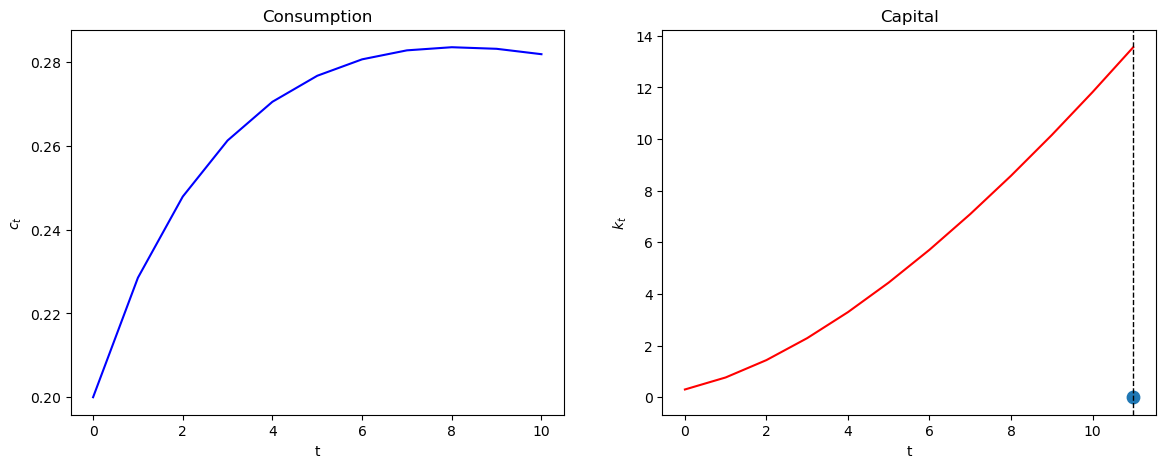

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

colors = ['blue', 'red']
titles = ['Consumption', 'Capital']
ylabels = ['$c_t$', '$k_t$']

T = paths[0].size - 1
for i in range(2):
    axs[i].plot(paths[i], c=colors[i])
    axs[i].set(xlabel='t', ylabel=ylabels[i], title=titles[i])

axs[1].scatter(T+1, 0, s=80)
axs[1].axvline(T+1, color='k', ls='--', lw=1)

plt.show()

Above is our constructed graph given these initial conditions, you may notice that our ending capital is not actually close to our $K_{t+1}$. Remember the relationship between the lagrange multiplier and consumption is an inverse. A multiplier that is too high implies our consumption was too low. We could manually do this process, but this would be pretty tedious and there is a much smarter way of doing things.

$\textbf{The Bisection Method}$

The bisection method is what we will be using to automate our process of choosing the correct c0. The set up is relatively simple. We run through our shooting method, if $K_{t+1} < 0$, we raise $\mu_{0}$. If $K_{t+1} > 0$, we lower $\mu_{0}$. Remember here that since we are choosing c0, the relationship is inverse when we automate this, for a $K_{t+1} > 0$, we will set our guess of $c_0$ as a new lower bound and vice versa. Then the bisection method will choose a new $c_0$ in between our upper and lower bound. In this bisection method,

$$c_{0} = \frac{\text{upper bound} + \text{lower bound}}{2} $$

In [ ]:
@jit
def bisection(pp, c0, k0, T=10, tol=1e-4, max_iter=500, k_ter=0, verbose=True):

    # initial boundaries for guess c0
    c0_upper = pp.f(k0) + (1 - pp.δ) * k0  
    c0_lower = 0

    i = 0
    while True:
        c_vec, k_vec = shooting(pp, c0, k0, T)
        error = k_vec[-1] - k_ter

        # check if the terminal condition is satisfied
        if np.abs(error) < tol:
            if verbose:
                print('Converged successfully on iteration ', i+1)
            return c_vec, k_vec

        i += 1
        if i == max_iter:
            if verbose:
                print('Convergence failed.')
            return c_vec, k_vec

        # if iteration continues, updates boundaries and guess of c0
        if error > 0:
            c0_lower = c0
        else:
            c0_upper = c0

        c0 = (c0_lower + c0_upper) / 2

In [ ]:
def plot_paths(pp, c0, k0, T_arr, k_ter=0, k_ss=None, axs=None):

    if axs is None:
        fix, axs = plt.subplots(1, 3, figsize=(16, 4))
    ylabels = ['$c_t$', '$k_t$', r'$\mu_t$']
    titles = ['Consumption', 'Capital', 'Lagrange Multiplier']

    c_paths = []
    k_paths = []
    for T in T_arr:
        c_vec, k_vec = bisection(pp, c0, k0, T, k_ter=k_ter, verbose=False)
        c_paths.append(c_vec)
        k_paths.append(k_vec)

        μ_vec = pp.u_prime(c_vec)
        paths = [c_vec, k_vec, μ_vec]

        for i in range(3):
            axs[i].plot(paths[i])
            axs[i].set(xlabel='t', ylabel=ylabels[i], title=titles[i])

        # Plot steady state value of capital
        if k_ss is not None:
            axs[1].axhline(k_ss, c='k', ls='--', lw=1)

        axs[1].axvline(T+1, c='k', ls='--', lw=1)
        axs[1].scatter(T+1, paths[1][-1], s=80)

    return c_paths, k_paths

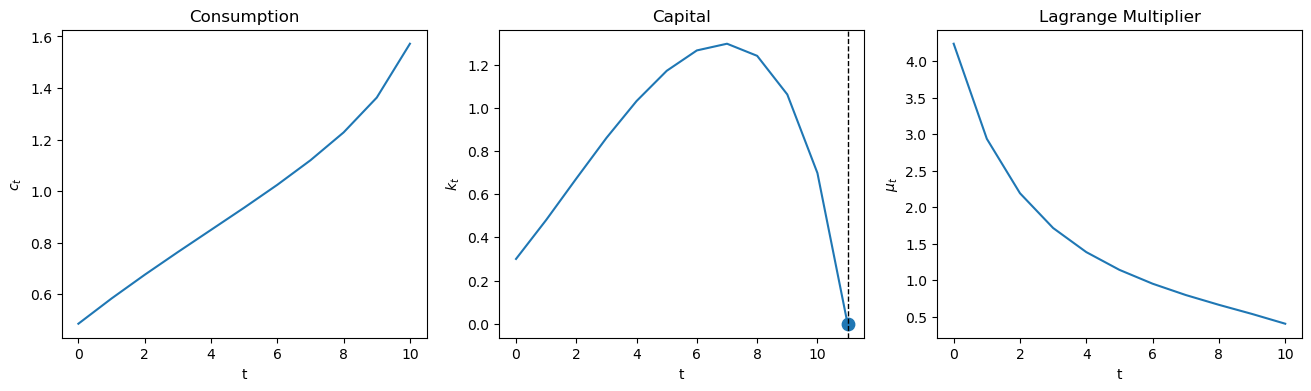

In [ ]:
plot_paths(pp, 0.3, 0.3, [10]);

You may have wondered earlier in our planning problem why we defined an inverse of the first derivative of the production function. That is because it is useful in sovling for our steady state mainly, for $K_{ss} = \bar{K}$ we f'can use how we solved for steady state of Consumption to solve for capital.

$$ 
1 + \rho = [f'(\bar{K}) + (1-\delta)] 
$$
for $\beta = \frac{1}{1+\rho} $

thereby

$$ 
\rho + \delta = f'(\bar{K})
$$ 
$$
f^{'-1}(\rho + \delta) = \bar{K}
$$


In [ ]:


ρ = 1 / pp.β - 1
k_ss = pp.f_prime_inv(ρ+pp.δ)

print(f'steady state for capital is: {k_ss}')

steady state for capital is: 9.57583816331462


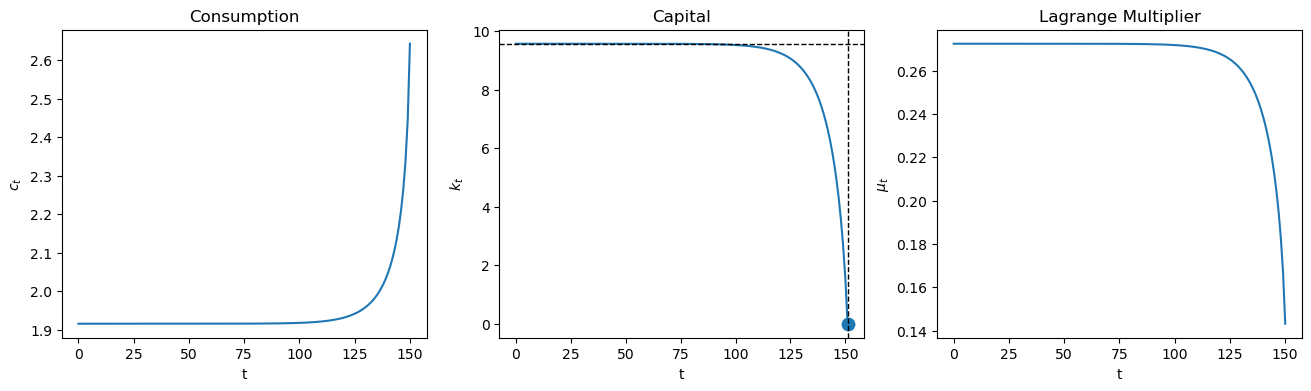

In [ ]:
plot_paths(pp, 0.3, k_ss, [150], k_ss=k_ss);

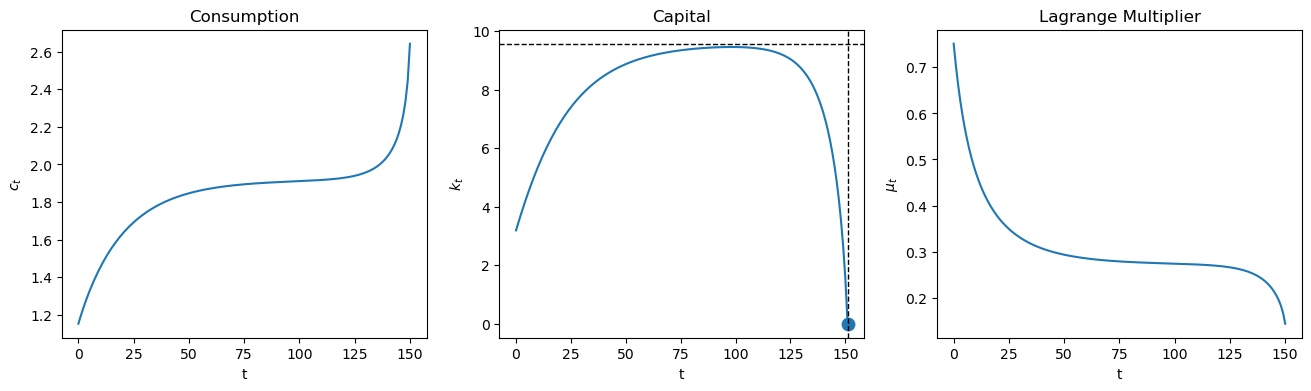

In [ ]:
plot_paths(pp, 0.3, k_ss/3, [150], k_ss=k_ss);

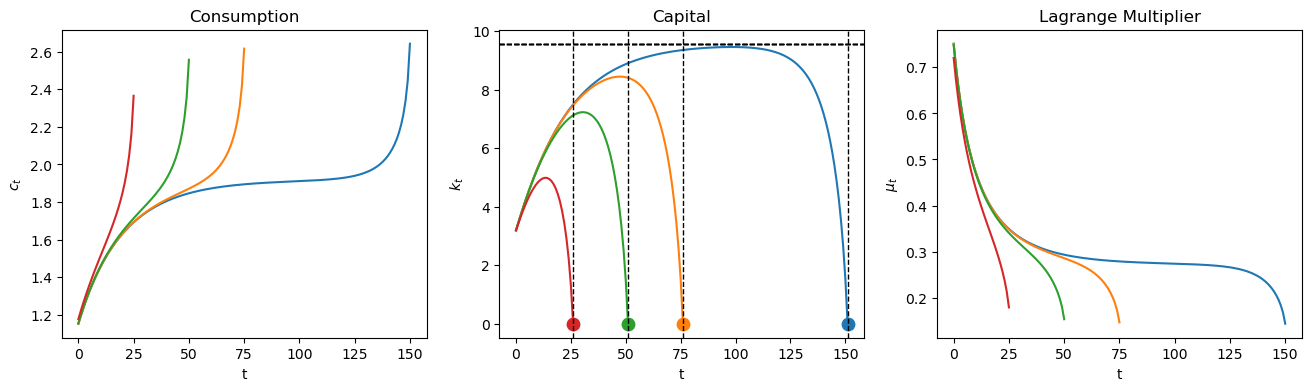

In [ ]:
plot_paths(pp, 0.3, k_ss/3, [150, 75, 50, 25], k_ss=k_ss);

Here we have some unique results. We notices that our dashed line (which marks our steady state) exists such that the greater horizon we place, the longer these values stay at our steady state. Below we give a more extreme example to illustrate the level at which these steady states are met for a longer period of time. At about 150, capital is specifically met as a steady state. The turnpike method will also state that our initial condition is not conditional on reaching the steady state for a T horizon large enough. We've written further code to demonstrate this below.

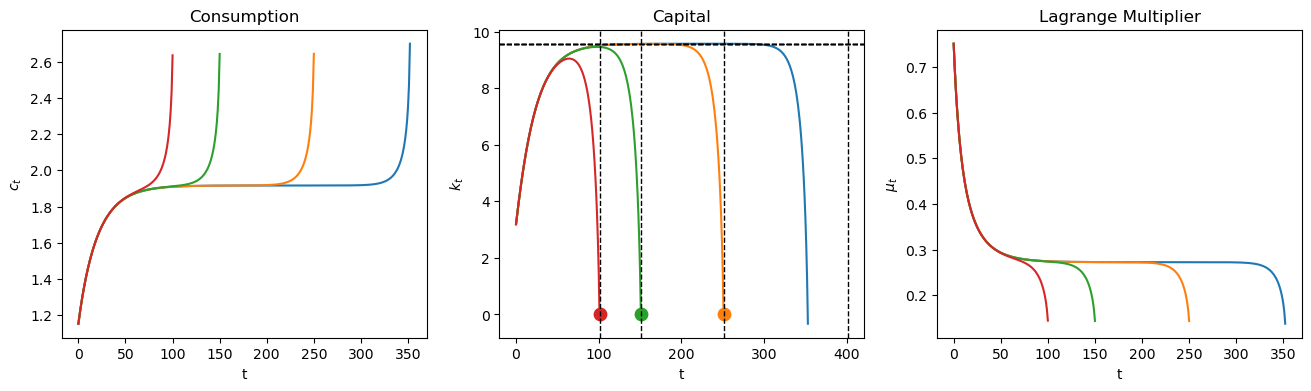

In [ ]:
plot_paths(pp, 0.3, k_ss/3, [400, 250, 150, 100], k_ss=k_ss);

In [ ]:
def plot_multiple_paths(pp, c0, k0s, T_arr, k_ter=0, k_ss=None, axs=None):
    if axs is None:
        fig, axs = plt.subplots(1, 3, figsize=(16, 4))
        
    ylabels = ['$c_t$', '$k_t$', r'$\mu_t$']
    titles = ['Consumption', 'Capital', 'Lagrange Multiplier']

    colors = plt.cm.viridis(np.linspace(0, 1, len(k0s)))
    
    all_c_paths = []
    all_k_paths = []
    
    for i, k0 in enumerate(k0s):
        k0_c_paths = []
        k0_k_paths = []
        
        for T in T_arr:
            c_vec, k_vec = bisection(pp, c0, k0, T, k_ter=k_ter, verbose=False)
            k0_c_paths.append(c_vec)
            k0_k_paths.append(k_vec)

            μ_vec = pp.u_prime(c_vec)
            paths = [c_vec, k_vec, μ_vec]

            for j in range(3):
                axs[j].plot(paths[j], color=colors[i], 
                           label=f'$k_0 = {k0:.2f}$' if j == 0 and T == T_arr[0] else "", alpha=0.7)
                axs[j].set(xlabel='t', ylabel=ylabels[j], title=titles[j])

            if k_ss is not None and i == 0 and T == T_arr[0]:
                axs[1].axhline(k_ss, c='k', ls='--', lw=1)

            axs[1].axvline(T+1, c='k', ls='--', lw=1)
            axs[1].scatter(T+1, paths[1][-1], s=80, color=colors[i])
        
        all_c_paths.append(k0_c_paths)
        all_k_paths.append(k0_k_paths)
    
    # Add legend if multiple initial points
    if len(k0s) > 1:
        axs[0].legend()

    return all_c_paths, all_k_paths

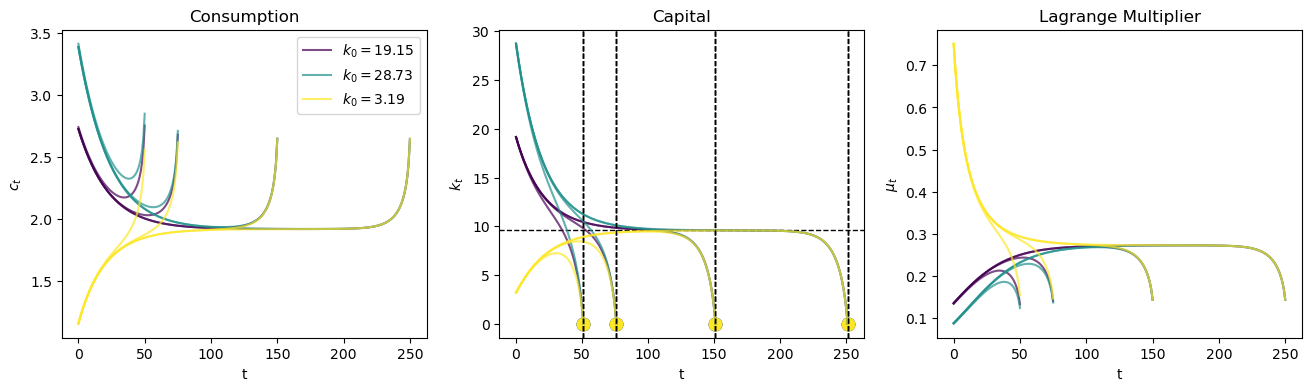

In [ ]:
_ = plot_multiple_paths(pp, 0.3, [k_ss*2, k_ss*3, k_ss/3], [250, 150, 75, 50], k_ss=k_ss)

We will move on now to describing the savings rate and a steady state for this, as well as moving on to building optimal paths for all these variables. We notice that our turning pike property follows an almost inverse relationship to consumption. This is a good check for where we went wrong in terms of coding and debugging any code.

In [ ]:
@jit
def saving_rate(pp, c_path, k_path):
    'Given paths of c and k, computes the path of saving rate.'
    production = pp.f(k_path[:-1])

    return (production - c_path) / production

In [ ]:
def plot_saving_rate(pp, c0, k0, T_arr, k_ter=0, k_ss=None, s_ss=None):

    fix, axs = plt.subplots(2, 2, figsize=(12, 9))

    c_paths, k_paths = plot_paths(pp, c0, k0, T_arr, k_ter=k_ter, k_ss=k_ss, axs=axs.flatten())

    for i, T in enumerate(T_arr):
        s_path = saving_rate(pp, c_paths[i], k_paths[i])
        axs[1, 1].plot(s_path)

    axs[1, 1].set(xlabel='t', ylabel='$s_t$', title='Saving rate')

    if s_ss is not None:
        axs[1, 1].hlines(s_ss, 0, np.max(T_arr), linestyle='--')
        

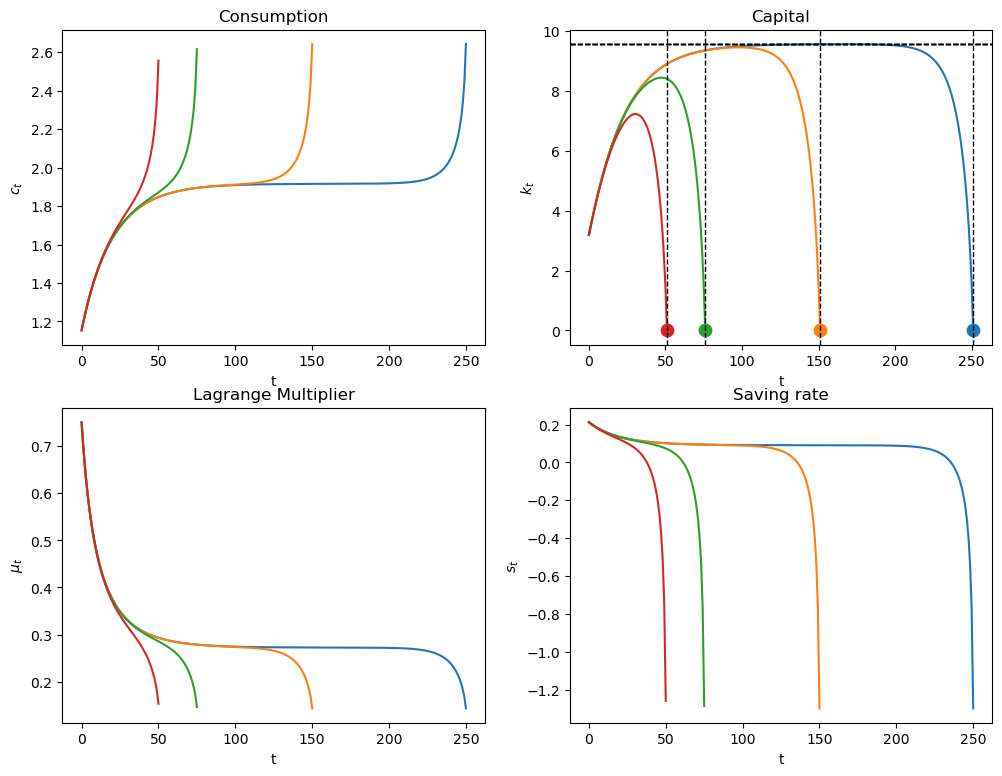

In [ ]:
plot_saving_rate(pp, 0.3, k_ss/3, [250, 150, 75, 50], k_ss=k_ss)

Naturally there is no horizon bigger then $+\infty$. This makes this a greater number we can set a limit approaching to as our $\emph{terminal condition}$. We will define this as
$$
\lim_{T \to +\infty} \beta^{T} u'(C_{T})K_{T+1} = 0
$$

This we can approximate with a starting path of any K and shoot towards our steady state Capital at some finite but large T+1.


Note that our savings rate steady state is:
$$
\frac{K^\delta{*}}{f(K^{*})}

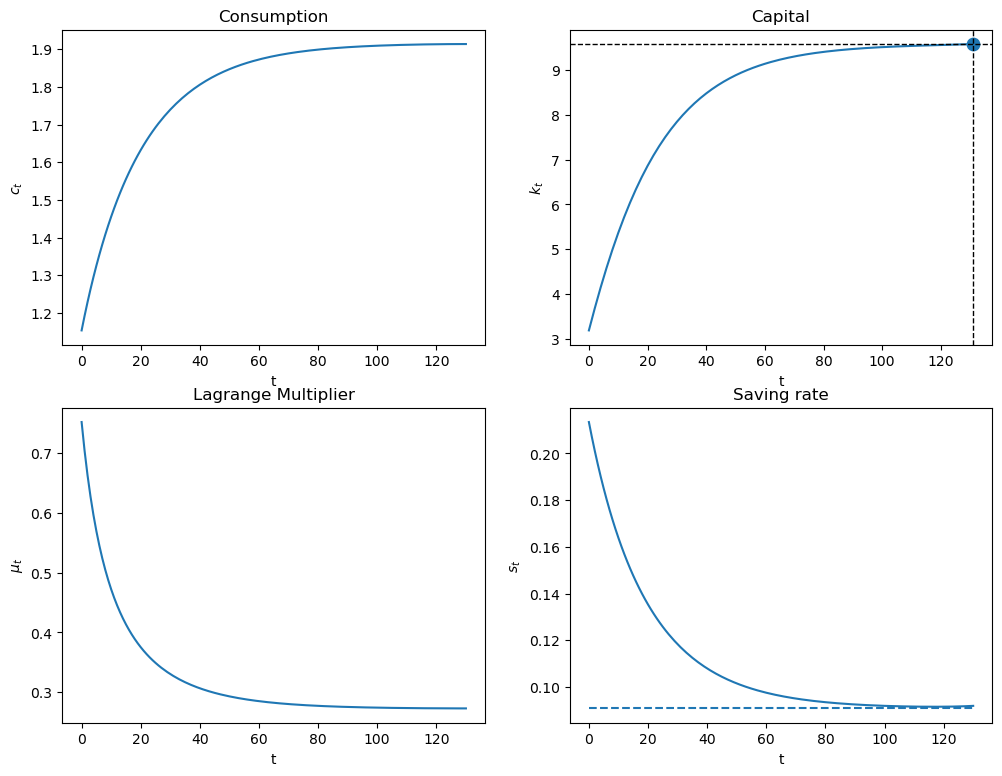

In [ ]:
# steady state of saving rate
s_ss = pp.δ * k_ss / pp.f(k_ss)

plot_saving_rate(pp, 0.3, k_ss/3, [130], k_ter=k_ss, k_ss=k_ss, s_ss=s_ss)

Let's note why it happened this way. If you see $K_{0} < K^{*}$. This should imply that $f'(k) > \rho + \delta$. Thereby for a $f''(K) < 0, f'(0)$ will fall until $f'(k) = \rho + \delta$

In [ ]:
@jit
def C_tilde(K, pp):

    return pp.f(K) + (1 - pp.δ) * K - pp.f_prime_inv(1 / pp.β - 1 + pp.δ)

We would now like the describe the relationship of Consumption and Capital in terms of their Phase Diagrams. Let K be on the ordinate Axis and C be on the Coordinate axis, this will correspond to x and y axes. We can use the Euler Consumption Equation to come up with a fixed point of consumption based on K. 
$$
\tilde{C}(K) = f(K) + (1-\delta)K - f^{'-1}(\frac{1}{\beta}-(1-\delta))
$$

for which a positive fixed point must have an RHS > 0. This is what defines the above C tilde, and for which the k_tilde will be constructed in a similar matter.



In [ ]:
@jit
def K_diff(K, C, pp):
    return pp.f(K) - pp.δ * K - C

@jit
def K_tilde(C, pp):

    res = brentq(K_diff, 1e-6, 100, args=(C, pp))

    return res.root

@jit
def K_tilde_diff(K, pp):

    K_out = K_tilde(C_tilde(K, pp), pp)

    return K - K_out

res = brentq(K_tilde_diff, 8, 10, args=(pp,))

Ks = res.root
Cs = C_tilde(Ks, pp)

Ks, Cs



(9.575838163314447, 1.9160839808123402)

In [ ]:
c_vec1, k_vec1 = bisection(pp, 5, 15, T=200, k_ter=Ks)
c_vec2, k_vec2 = bisection(pp, 1e-3, 1e-3, T=200, k_ter=Ks)

Converged successfully on iteration  46
Converged successfully on iteration  51


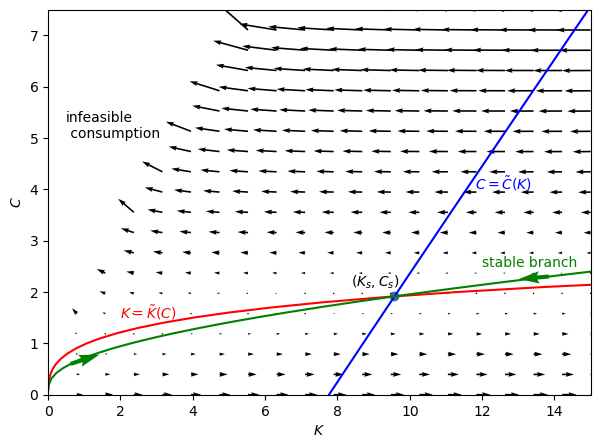

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

K_range = np.arange(1e-1, 15, 0.1)
C_range = np.arange(1e-1, 2.3, 0.1)

# C tilde
ax.plot(K_range, [C_tilde(Ks, pp) for Ks in K_range], color='b')
ax.text(11.8, 4, r'$C=\tilde{C}(K)$', color='b')

# K tilde
ax.plot([K_tilde(Cs, pp) for Cs in C_range], C_range, color='r')
ax.text(2, 1.5, r'$K=\tilde{K}(C)$', color='r')

# stable branch
ax.plot(k_vec1[:-1], c_vec1, color='g')
ax.plot(k_vec2[:-1], c_vec2, color='g')
ax.quiver(k_vec1[5], c_vec1[5],
          k_vec1[6]-k_vec1[5], c_vec1[6]-c_vec1[5],
          color='g')
ax.quiver(k_vec2[5], c_vec2[5],
          k_vec2[6]-k_vec2[5], c_vec2[6]-c_vec2[5],
          color='g')
ax.text(12, 2.5, r'stable branch', color='g')

# (Ks, Cs)
ax.scatter(Ks, Cs)
ax.text(Ks-1.2, Cs+0.2, '$(K_s, C_s)$')

# arrows
K_range = np.linspace(1e-3, 15, 20)
C_range = np.linspace(1e-3, 7.5, 20)
K_mesh, C_mesh = np.meshgrid(K_range, C_range)

next_K, next_C = pp.next_k_c(K_mesh, C_mesh)
ax.quiver(K_range, C_range, next_K-K_mesh, next_C-C_mesh)

# infeasible consumption area
ax.text(0.5, 5, "infeasible\n consumption")

ax.set_ylim([0, 7.5])
ax.set_xlim([0, 15])

ax.set_xlabel('$K$')
ax.set_ylabel('$C$')

plt.show()

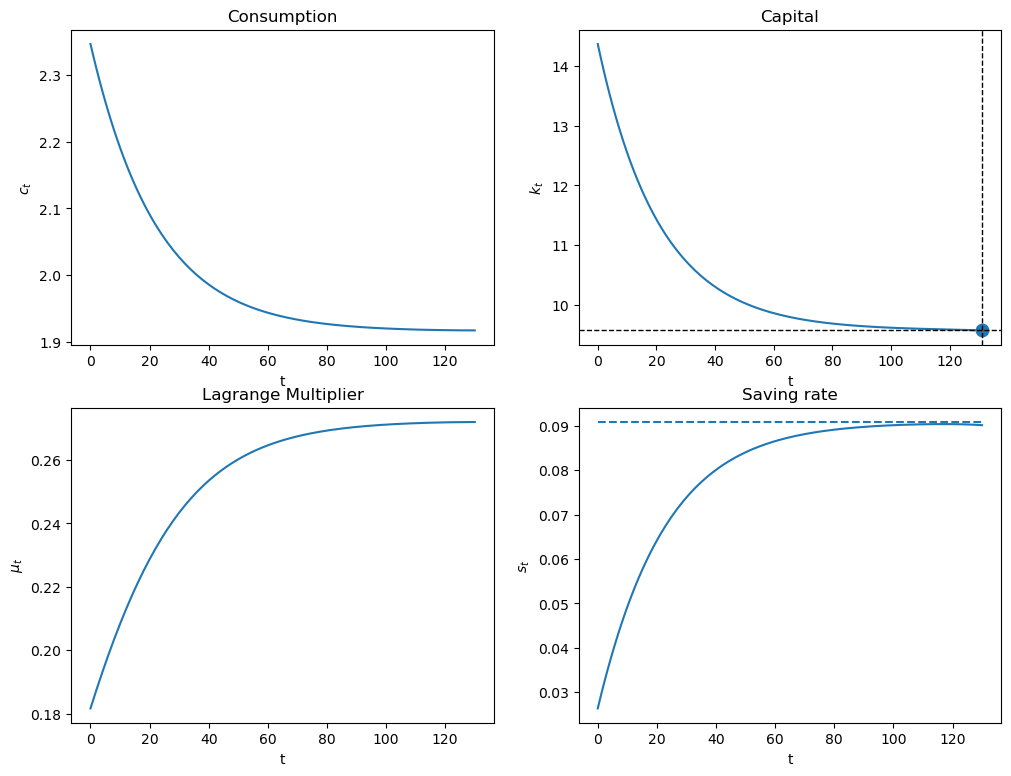

In [ ]:
# Practice Exercise 1

plot_saving_rate(pp, 0.3, k_ss*1.5, [130], k_ter=k_ss, k_ss=k_ss, s_ss=s_ss)


$
\textbf{Cass Koopmans Model with Distortionary Taxes}
$

Our feasible allocation works as:

$$
g_{t} + c_{t} +x_{t} \leq F(k_{t}, n_{t})
$$

for $g_{t}$ as government purchases at time t, $x_{t}$ as gross investment and $F(k_{t}, n_{t})$. 

Physical Capital evolves in the generic fashion:

$$
k_{t+1} = (1-\delta)k_{t}+x_{t}
$$

for $\delta \in (0,1)$ as the depreciation rate.

$$
g_{t} + c_{t} + k_{t+1} \leq F(k_{t}, n_{t}) + (1-\delta)k_{t}
$$

Our price system will create the components that create an equillibrium system. Recall that your representative household owns capital, they make the investment choices, adn they rent out capital to some representative production firm. (This is the exact set up of most problems in Intermediate Macro). Our price sequence wokrs as $[q_{t}, \eta_{t}, w_{t}]_{t=0}^{\infty}$

For which $q_{t}$ is the time 0 pre tax price of a unit of investment or a unit of consumption. $\eta_{t}$ is the pretax rental price the firm pays to the household owning the capital. $w_{t}$ is the wages or rental price of labor that the household is payed by the firm. $[\tau_{ct}, \tau_{kt}, \tau_{nt}, \tau_{ht}]_{t=0}^{\infty}$

* $\tau_{ct}$  is a tax rate on consumption in time t
* $\tau_{kt}$ is a tax on renting capital at t
* $\tau_{nt}$ is a tax on income in t
* $\tau_{ht}$ is a lump sum tax on a consumer at t

The method for solving this is a standard lagrangian foc that will be $\textbf{written out in detail later}$.

We will now begen then coding up this model of distortionary equillibriums.




In [ ]:
import numpy as np
from scipy.optimize import root
import matplotlib .pyplot as plt
from collections import namedtuple
from mpmath import mp, mpf, findroot
from warnings import warn

# We are setting a precision from our mpmath package to 40 decimal places. This is important for the root finding algorithm to work properly.
mp.dps = 40
mp.pretty = True
   
α



SyntaxError: unexpected character after line continuation character (1793712868.py, line 12)

In [ ]:
# class Params:
#     # Fixed Paramaters
#     β: float = 0.96, # Future Discounting
#     α: float = 0.33, # Share of Capital in Production Function (Cobb Douglas)
#     δ: float = 0.1, # Depreciation rate of Physical Capital
#     Z: float = 1.0, # Total Factor Productivity in Cobb-Douglas
#     T: int = 16, # Total Periods
#     n_age: int = 16, # Total age of Agents
#     # Building Time Dependent Parameters
#     Ω = np.ndarray = None, # Productivity Paramater
#     θ = np.ndarray = None, # Share of Human Capital for Initial Capital
#     ρ = np.ndarray = None, # Elasticity of Substitution 
#     ϕ = np.ndarray = None # Share of Parental Investment


# class Model:
    
#     def __init__(self, p: Params, k0, h_age0, L):
#         self.p = p
#         self.K0 = K0
#         self.h_age0 = h_age0
#         self.L = L

#     def output(p, K, H_agg, L):
#         p = self.p
#         return p.Z*(K**p.α)*(H_agg*L)**(1-p.α)

#     def skill_form(p, X, H, H_p, a, t): # Turn all of these into first order conditions
#         p = self.p
#         inner = (p.phi[a] * X[a]**p.ρ[a]) + (p.theta[a] * H[a]**p.ρ[a]) + (1 - p.theta[a] - p.phi[a] * X[a]**p.ρ[a])
#         return p.Ω[a] * inner**(1\p.rho[a])

#     def H_bar_form(p, H, H_bar):
#         p = self.p
#         H = np.sum(H) \ np.abs(S)

#     def utility(p, C):
#         return np.sum(p.β**(np
#         .arange(len(C)))*np.log(C))        